In [1]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

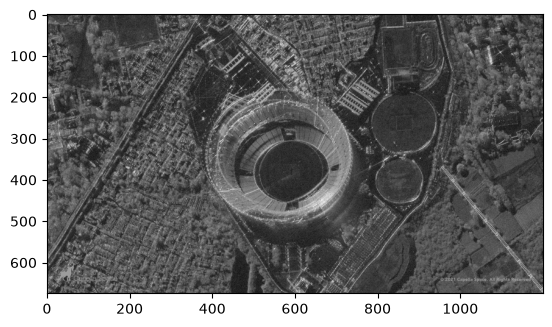

In [3]:
## Пункт 1. Загрузка исходного изображения

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap='gray')
plt.show()

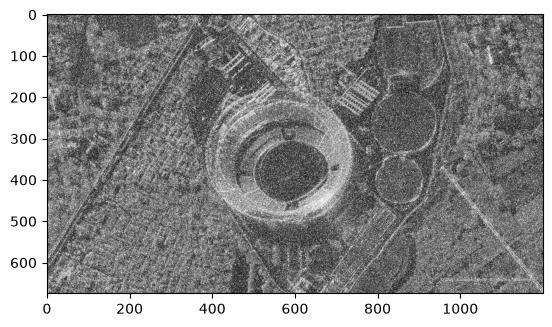

In [4]:
## Пункт 2. Добавление гауссовского шума

mean = 0
stddev = 90

noise_gauss = np.zeros(image_gray.shape, dtype=np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap='gray')
plt.show()

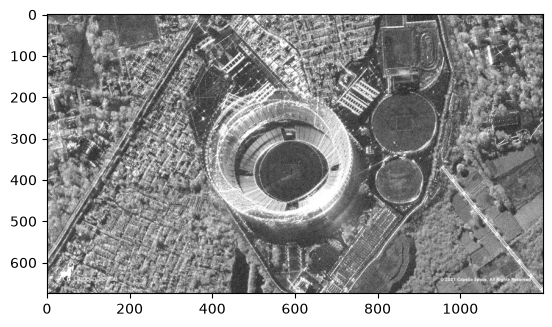

In [5]:
## Пункт 3. Добавление постоянного шума

noise_value = 100

noise_const = np.ones(image_gray.shape, dtype=np.uint8) * noise_value
image_noise_const = cv2.add(image_gray, noise_const)

plt.imshow(image_noise_const, cmap='gray')
plt.show()

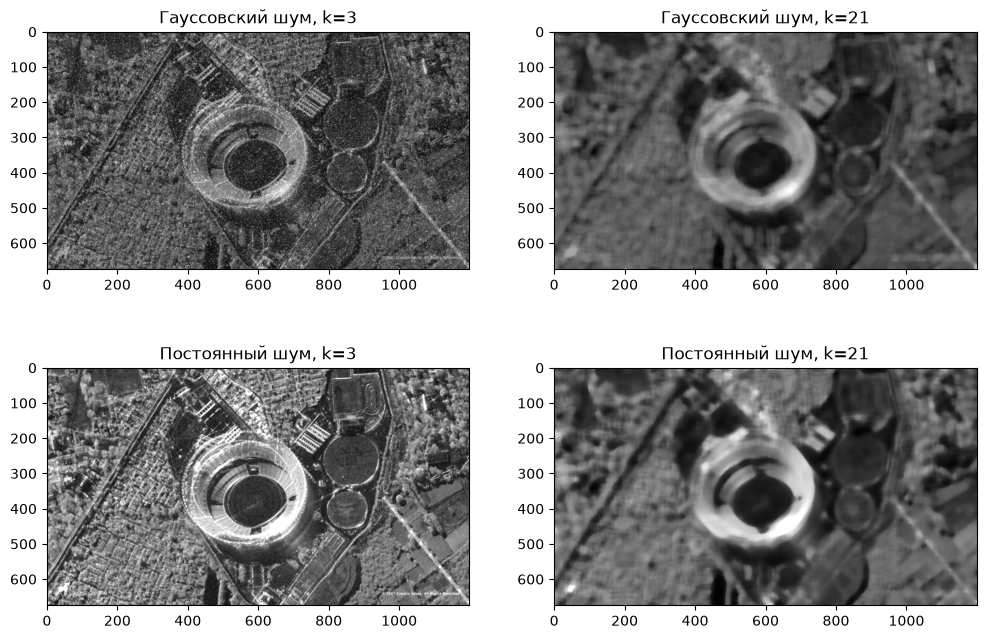

In [6]:
## Пункт 4. Медианный фильтр с различными параметрами

median_gauss_3 = cv2.medianBlur(image_noise_gauss, 3)
median_gauss_21 = cv2.medianBlur(image_noise_gauss, 21)

median_const_3 = cv2.medianBlur(image_noise_const, 3)
median_const_21 = cv2.medianBlur(image_noise_const, 21)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(median_gauss_3, cmap='gray')
plt.title('Гауссовский шум, k=3')

plt.subplot(2, 2, 2)
plt.imshow(median_gauss_21, cmap='gray')
plt.title('Гауссовский шум, k=21')

plt.subplot(2, 2, 3)
plt.imshow(median_const_3, cmap='gray')
plt.title('Постоянный шум, k=3')

plt.subplot(2, 2, 4)
plt.imshow(median_const_21, cmap='gray')
plt.title('Постоянный шум, k=21')

plt.show()

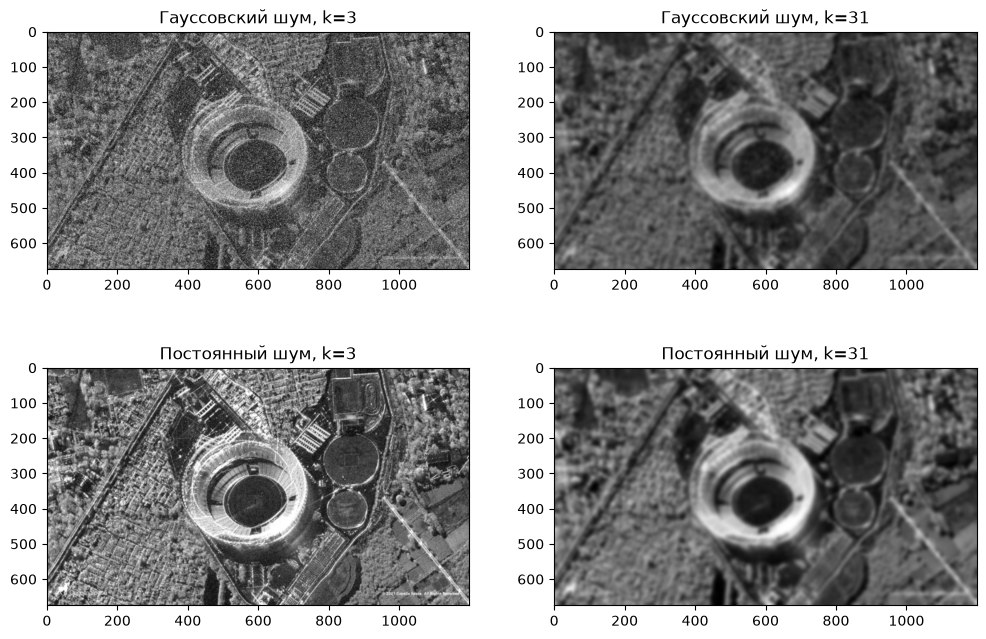

In [7]:
## Пункт 5. Фильтр Гаусса с различными параметрами

gauss_gauss_3 = cv2.GaussianBlur(image_noise_gauss, (3, 3), 0)
gauss_gauss_31 = cv2.GaussianBlur(image_noise_gauss, (31, 31), 0)

gauss_const_3 = cv2.GaussianBlur(image_noise_const, (3, 3), 0)
gauss_const_31 = cv2.GaussianBlur(image_noise_const, (31, 31), 0)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(gauss_gauss_3, cmap='gray')
plt.title('Гауссовский шум, k=3')

plt.subplot(2, 2, 2)
plt.imshow(gauss_gauss_31, cmap='gray')
plt.title('Гауссовский шум, k=31')

plt.subplot(2, 2, 3)
plt.imshow(gauss_const_3, cmap='gray')
plt.title('Постоянный шум, k=3')

plt.subplot(2, 2, 4)
plt.imshow(gauss_const_31, cmap='gray')
plt.title('Постоянный шум, k=31')

plt.show()

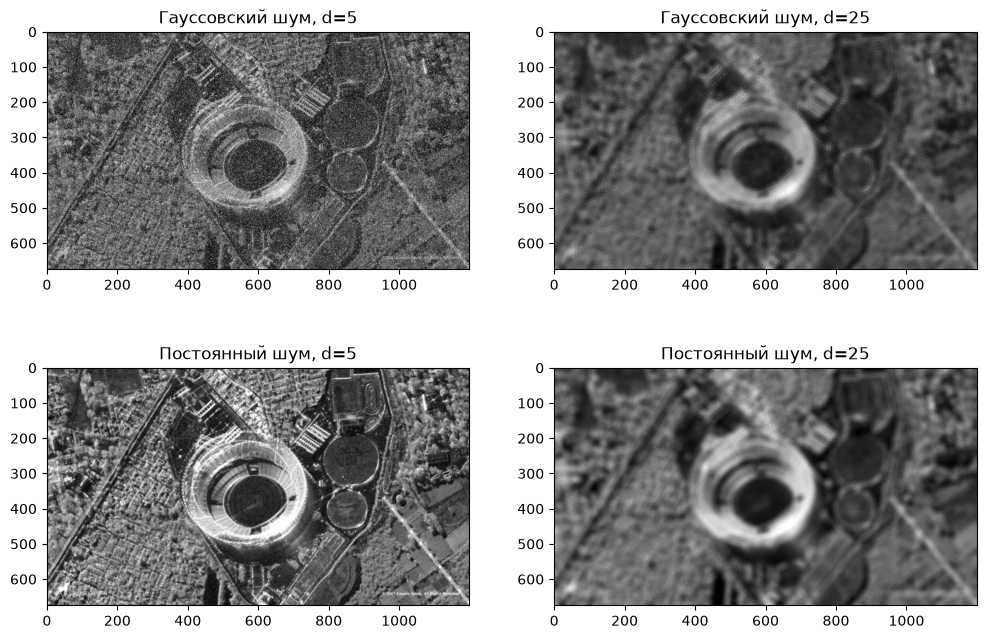

In [8]:
## Пункт 6. Билатеральный фильтр с различными параметрами

bilat_gauss_5 = cv2.bilateralFilter(image_noise_gauss, 5, 50, 50)
bilat_gauss_25 = cv2.bilateralFilter(image_noise_gauss, 25, 150, 150)

bilat_const_5 = cv2.bilateralFilter(image_noise_const, 5, 50, 50)
bilat_const_25 = cv2.bilateralFilter(image_noise_const, 25, 150, 150)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(bilat_gauss_5, cmap='gray')
plt.title('Гауссовский шум, d=5')

plt.subplot(2, 2, 2)
plt.imshow(bilat_gauss_25, cmap='gray')
plt.title('Гауссовский шум, d=25')

plt.subplot(2, 2, 3)
plt.imshow(bilat_const_5, cmap='gray')
plt.title('Постоянный шум, d=5')

plt.subplot(2, 2, 4)
plt.imshow(bilat_const_25, cmap='gray')
plt.title('Постоянный шум, d=25')

plt.show()

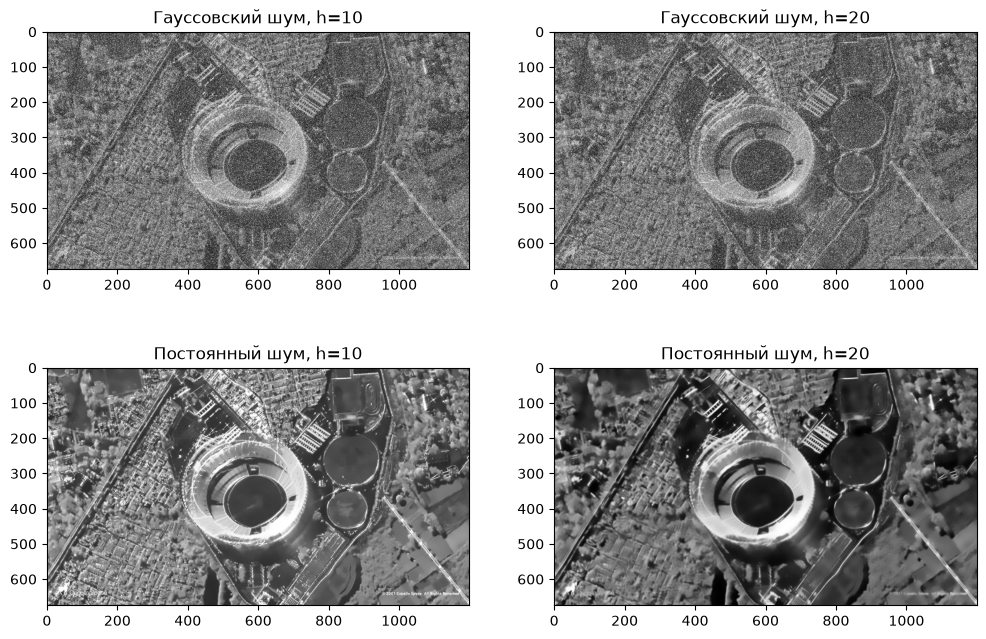

In [9]:
## Пункт 7. Фильтр нелокальных средних с различными параметрами

nlm_gauss_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
nlm_gauss_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)

nlm_const_10 = cv2.fastNlMeansDenoising(image_noise_const, h=10)
nlm_const_20 = cv2.fastNlMeansDenoising(image_noise_const, h=20)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(nlm_gauss_10, cmap='gray')
plt.title('Гауссовский шум, h=10')

plt.subplot(2, 2, 2)
plt.imshow(nlm_gauss_20, cmap='gray')
plt.title('Гауссовский шум, h=20')

plt.subplot(2, 2, 3)
plt.imshow(nlm_const_10, cmap='gray')
plt.title('Постоянный шум, h=10')

plt.subplot(2, 2, 4)
plt.imshow(nlm_const_20, cmap='gray')
plt.title('Постоянный шум, h=20')

plt.show()

In [10]:
## Пункт 8. Сравнение результатов и определение лучшего фильтра

results = [
    ('Медианный k=3', median_gauss_3, median_const_3),
    ('Медианный k=21', median_gauss_21, median_const_21),

    ('Гауссовский k=3', gauss_gauss_3, gauss_const_3),
    ('Гауссовский k=31', gauss_gauss_31, gauss_const_31),

    ('Билатеральный d=5', bilat_gauss_5, bilat_const_5),
    ('Билатеральный d=25', bilat_gauss_25, bilat_const_25),

    ('Нелокальных средних h=10', nlm_gauss_10, nlm_const_10),
    ('Нелокальных средних h=20', nlm_gauss_20, nlm_const_20)
]

metrics = []

print(f'{"Фильтр / Шум":<48} | {"MSE":>10} | {"SSIM":>8}')
print('-' * 73)

for name, gauss_img, const_img in results:

    mse_gauss = mean_squared_error(image_gray, gauss_img)
    ssim_gauss = structural_similarity(image_gray, gauss_img)

    mse_const = mean_squared_error(image_gray, const_img)
    ssim_const = structural_similarity(image_gray, const_img)

    metrics.append(
        (name, mse_gauss, ssim_gauss, mse_const, ssim_const)
    )

    print(f'{name + " (Шум Гаусса)":<48} | {mse_gauss:>10.2f} | {ssim_gauss:>8.4f}')
    print(f'{name + " (Постоянный шум)":<48} | {mse_const:>10.2f} | {ssim_const:>8.4f}')

print('-' * 73)

best_gauss_mse = min(metrics, key=lambda x: x[1])
best_gauss_ssim = max(metrics, key=lambda x: x[2])

best_const_mse = min(metrics, key=lambda x: x[3])
best_const_ssim = max(metrics, key=lambda x: x[4])

print()
print('Шум Гаусса:')
print(f'  Лучший по MSE  (минимальная ошибка): {best_gauss_mse[0]} '
      f'(MSE: {best_gauss_mse[1]:.2f})')
print(f'  Лучший по SSIM (максимальное сходство): {best_gauss_ssim[0]} '
      f'(SSIM: {best_gauss_ssim[2]:.4f})')

print()
print('-' * 73)

print('Постоянный шум:')
print(f'  Лучший по MSE  (минимальная ошибка): {best_const_mse[0]} '
      f'(MSE: {best_const_mse[3]:.2f})')
print(f'  Лучший по SSIM (максимальное сходство): {best_const_ssim[0]} '
      f'(SSIM: {best_const_ssim[4]:.4f})')

Фильтр / Шум                                     |        MSE |     SSIM
-------------------------------------------------------------------------
Медианный k=3 (Шум Гаусса)                       |     875.28 |   0.4637
Медианный k=3 (Постоянный шум)                   |    9948.89 |   0.5855
Медианный k=21 (Шум Гаусса)                      |     860.92 |   0.2525
Медианный k=21 (Постоянный шум)                  |   10018.12 |   0.1889
Гауссовский k=3 (Шум Гаусса)                     |    1612.60 |   0.4735
Гауссовский k=3 (Постоянный шум)                 |    9995.70 |   0.6252
Гауссовский k=31 (Шум Гаусса)                    |    1637.30 |   0.2902
Гауссовский k=31 (Постоянный шум)                |   10341.29 |   0.2234
Билатеральный d=5 (Шум Гаусса)                   |    2306.59 |   0.2743
Билатеральный d=5 (Постоянный шум)               |    9907.58 |   0.5604
Билатеральный d=25 (Шум Гаусса)                  |    1467.96 |   0.3353
Билатеральный d=25 (Постоянный шум)              |